This goal of this script is to create an orthology matrix where to integrate normalised protein expression data and annotations to be able to compare the 19 founders proteomes 

In [4]:
# =========================================================
# Arabidopsis Founders Proteomics Analysis
# Directory structure (orthology-focused)
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Base directory
# ---------------------------------------------------------

BASE_DIR = Path("/home/ggiordano/snap/main")

# ---------------------------------------------------------
# Import directories
# ---------------------------------------------------------

IMPORT_DIR = BASE_DIR / "import"

TAIR_ANNOT = IMPORT_DIR / "at_founders" / "at_TAIR10_proteome_annotations"
DIAMOND_DIR = IMPORT_DIR / "at_founders" / "col0mott_vs_col0_uniprot"
PG_DIR = IMPORT_DIR / "at_founders" / "matrix"

ORTHO_DIR = IMPORT_DIR / "at_founders" / "orthology_matrix"

# ---------------------------------------------------------
# Output directory (UPDATED)
# ---------------------------------------------------------

DATA_DIR = BASE_DIR / "data" / "at_founders" / "orthology"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", DATA_DIR)

EXPORT_DIR = BASE_DIR / "export" / "at_founders" / "arat_orthology"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", EXPORT_DIR)
# ---------------------------------------------------------
# Input files
# ---------------------------------------------------------

ANNOT_FILE = TAIR_ANNOT / "at_ref_proteome_UP000006548_2026_03_15.tsv"
DIAMOND_FILE = DIAMOND_DIR / "col0_vs_tair.tsv"
ORTHO_FILE = ORTHO_DIR / "Orthogroups.tsv"

# ---------------------------------------------------------
# Load orthology
# ---------------------------------------------------------

orthology = pd.read_csv(ORTHO_FILE, sep="\t")

print("Annotation:", ANNOT_FILE)
print("Diamond:", DIAMOND_FILE)
print("Orthology:", ORTHO_FILE)
print("Protein groups:", PG_DIR)

Output directory: /home/ggiordano/snap/main/data/at_founders/orthology
Output directory: /home/ggiordano/snap/main/export/at_founders/arat_orthology
Annotation: /home/ggiordano/snap/main/import/at_founders/at_TAIR10_proteome_annotations/at_ref_proteome_UP000006548_2026_03_15.tsv
Diamond: /home/ggiordano/snap/main/import/at_founders/col0mott_vs_col0_uniprot/col0_vs_tair.tsv
Orthology: /home/ggiordano/snap/main/import/at_founders/orthology_matrix/Orthogroups.tsv
Protein groups: /home/ggiordano/snap/main/import/at_founders/matrix


In [18]:
# =========================================================
# Load annotation and orthology data
# =========================================================

# TAIR annotation
tair_annot = pd.read_csv(ANNOT_FILE, sep="\t")

# Diamond results
diamond = pd.read_csv(
    DIAMOND_FILE,
    sep="\t",
    header=None,
    names=["query", "subject", "pident", "length", "qlen", "slen", "evalue", "bitscore"]
)

# ---------------------------------------------------------
# Orthology matrix (assigned)
# ---------------------------------------------------------

orthology = pd.read_csv(ORTHO_FILE, sep="\t")

# ---------------------------------------------------------
# Load unassigned orthogroups
# ---------------------------------------------------------

UNASSIGNED_FILE = Path(
    "/home/ggiordano/snap/main/import/at_founders/orthology_matrix/Orthogroups_UnassignedGenes.tsv"
)

orthology_unassigned = pd.read_csv(UNASSIGNED_FILE, sep="\t")

# =========================================================
# Build unassigned_dict from Orthogroups_UnassignedGenes
# =========================================================

unassigned_dict = {}

for col in orthology_unassigned.columns:

    if col == "Orthogroup":
        continue

    acc = resolve_accession(col, pg_tables_norm.keys()) if 'pg_tables_norm' in globals() else col

    # fallback: use column name directly if resolve not available yet
    if acc is None:
        acc = col

    genes = orthology_unassigned[col].dropna().astype(str).tolist()

    # split in case multiple entries per cell
    genes = [
        g.strip()
        for cell in genes
        for g in str(cell).split(",")
        if g.strip()
    ]

    unassigned_dict[acc] = set(genes)

print("\nUnassigned genes loaded:")
for acc in unassigned_dict:
    print(acc, len(unassigned_dict[acc]))

# ---------------------------------------------------------
# Sanity check (columns must match exactly)
# ---------------------------------------------------------

if list(orthology.columns) != list(orthology_unassigned.columns):
    raise ValueError("Column mismatch between Orthogroups and UnassignedGenes")

# ---------------------------------------------------------
# Append unassigned rows
# ---------------------------------------------------------

orthology = pd.concat(
    [orthology, orthology_unassigned],
    ignore_index=True
)

# ---------------------------------------------------------
# Output info
# ---------------------------------------------------------

print("Annotation:", tair_annot.shape)
print("Diamond:", diamond.shape)
print("Orthology matrix (combined):", orthology.shape)
print("Added unassigned orthogroups:", orthology_unassigned.shape[0])


Unassigned genes loaded:
Bur 46
Can 181
Col 58
Ct 103
Edi 22
Hi 335
Kn 103
Ler 64
Mt 40
No 120
Oy 104
Po 74
Rsch 52
Sf 142
Tsu 159
Wil 184
Ws 33
Wu 213
Zu 29
Annotation: (39273, 10)
Diamond: (28323, 8)
Orthology matrix (combined): (30760, 20)
Added unassigned orthogroups: 2062


In [6]:
# =========================================================
# Load and clean protein groups + export filtered versions
# =========================================================

PG_FILTERED_DIR = DATA_DIR / "pG_filtered"
PG_FILTERED_DIR.mkdir(parents=True, exist_ok=True)

print("Filtered PG output directory:", PG_FILTERED_DIR)

pg_files = sorted(PG_DIR.glob("*.csv"))

pg_tables = {}
pg_stats = []

for f in pg_files:

    acc = f.stem.split("_")[0]   # Bur, Can, Col, etc

    df = pd.read_csv(f)

    # -----------------------------
    # Count BEFORE filtering
    # -----------------------------
    n_before = df.shape[0]

    # -----------------------------
    # Filtering steps
    # -----------------------------
    # remove contaminants
    df_filtered = df[~df["Protein.Group"].str.contains("cRAP", na=False)].copy()

    # keep first protein only
    df_filtered["Protein.Group"] = df_filtered["Protein.Group"].str.split(";").str[0]

    # keep only ibaq columns
    ibaq_cols = [c for c in df_filtered.columns if "iBAQ" in c]
    df_filtered = df_filtered[["Protein.Group"] + ibaq_cols]

    # -----------------------------
    # Count AFTER filtering
    # -----------------------------
    n_after = df_filtered.shape[0]
    n_removed = n_before - n_after

    # -----------------------------
    # Store table
    # -----------------------------
    pg_tables[acc] = df_filtered

    # -----------------------------
    # Save filtered table
    # -----------------------------
    out_file = PG_FILTERED_DIR / f"{acc}_protein_groups_filtered.csv"
    df_filtered.to_csv(out_file, index=False)

    # -----------------------------
    # Collect stats
    # -----------------------------
    pg_stats.append({
        "accession": acc,
        "protein_groups_before": n_before,
        "protein_groups_after": n_after,
        "protein_groups_removed": n_removed
    })

    print(
        f"{acc} | before: {n_before} | after: {n_after} | removed: {n_removed}"
    )

# ---------------------------------------------------------
# Summary table
# ---------------------------------------------------------

pg_stats = pd.DataFrame(pg_stats).sort_values("accession")

print("\nProtein group filtering summary:")
print(pg_stats)

# optional: save summary
stats_file = PG_FILTERED_DIR / "protein_group_filtering_summary.tsv"
pg_stats.to_csv(stats_file, sep="\t", index=False)

print("Summary saved:", stats_file)

Filtered PG output directory: /home/ggiordano/snap/main/data/at_founders/orthology/pG_filtered
Bur | before: 10411 | after: 10397 | removed: 14
Can | before: 10779 | after: 10768 | removed: 11
Col | before: 10716 | after: 10693 | removed: 23
Ct | before: 10292 | after: 10274 | removed: 18
Edi | before: 10306 | after: 10286 | removed: 20
Hi | before: 10613 | after: 10601 | removed: 12
Kn | before: 10290 | after: 10278 | removed: 12
Ler | before: 10194 | after: 10175 | removed: 19
Mt | before: 10705 | after: 10692 | removed: 13
No | before: 10184 | after: 10165 | removed: 19
Oy | before: 10783 | after: 10769 | removed: 14
Po | before: 10235 | after: 10223 | removed: 12
Rsch | before: 10213 | after: 10191 | removed: 22
Sf | before: 10364 | after: 10354 | removed: 10
Tsu | before: 10642 | after: 10624 | removed: 18
Wil | before: 10406 | after: 10395 | removed: 11
Ws | before: 10410 | after: 10398 | removed: 12
Wu | before: 10294 | after: 10282 | removed: 12
Zu | before: 10590 | after: 1058


Replicate QC summary:
  accession               replicate  total_intensity  median_intensity  \
0       Bur   iBAQ_Bur_141_51_1_515    131305.776629         13.214712   
1       Bur   iBAQ_Bur_152_62_1_529    131038.001212         13.174749   
2       Bur   iBAQ_Bur_227_96_1_812    132742.227404         13.206619   
3       Bur  iBAQ_Bur_261_134_1_733    136651.812229         13.504330   
4       Can   iBAQ_Can_133_43_1_375    134433.917913         13.428831   

   missing_values  
0             482  
1             458  
2             367  
3             307  
4             765  
QC metrics saved: /home/ggiordano/snap/main/data/at_founders/orthology/pG_filtered/replicate_qc_metrics.tsv
Saved: /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_total_intensity.pdf and /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_total_intensity.jpeg


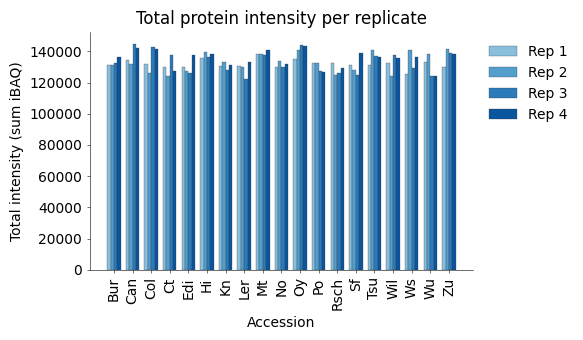

Saved: /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_median_intensity.pdf and /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_median_intensity.jpeg


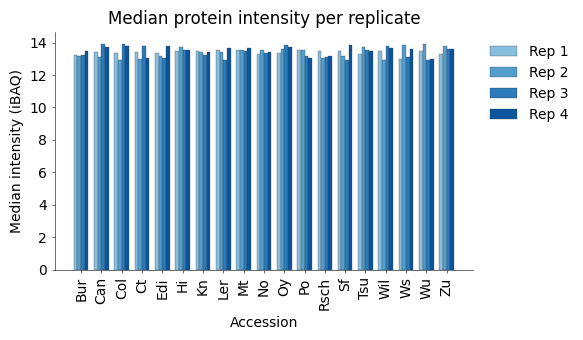

Saved: /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_missing_values.pdf and /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_missing_values.jpeg


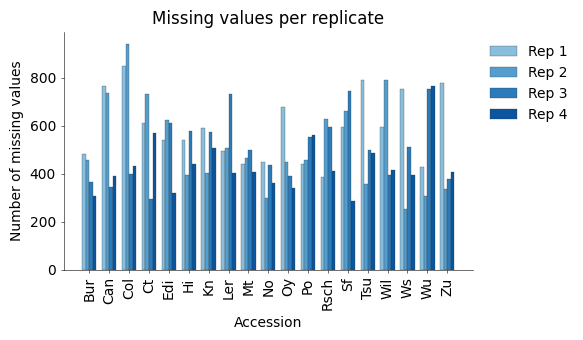

In [7]:
# ---------------------------------------------------------
# Compute replicate-level statistics
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

replicate_stats = []

for acc, df in pg_tables.items():

    ibaq_cols = [c for c in df.columns if "iBAQ" in c]

    for col in ibaq_cols:

        values = pd.to_numeric(df[col], errors="coerce")

        replicate_stats.append({
            "accession": acc,
            "replicate": col,
            "total_intensity": np.nansum(values),
            "median_intensity": np.nanmedian(values),
            "missing_values": values.isna().sum()
        })

replicate_stats = pd.DataFrame(replicate_stats)

print("\nReplicate QC summary:")
print(replicate_stats.head())

# ---------------------------------------------------------
# Save QC table
# ---------------------------------------------------------

qc_file = PG_FILTERED_DIR / "replicate_qc_metrics.tsv"
replicate_stats.to_csv(qc_file, sep="\t", index=False)

print("QC metrics saved:", qc_file)

# ---------------------------------------------------------
# Plot settings / helper variables
# ---------------------------------------------------------

# consistent ordering
replicate_stats = replicate_stats.sort_values(["accession", "replicate"]).reset_index(drop=True)

accessions = replicate_stats["accession"].unique()
n_acc = len(accessions)

rep_counts = replicate_stats.groupby("accession").size()
replicates_per_acc = rep_counts.iloc[0]

# safety check
if not (rep_counts == replicates_per_acc).all():
    raise ValueError("Not all accessions have the same number of iBAQ replicate columns.")

x = np.arange(n_acc)
bar_width = 0.18

# figure size
fig_width = 7.0
fig_height = 3.5

# ---------------------------------------------------------
# Plot 1 — total intensity
# ---------------------------------------------------------

rep_colors = sns.color_palette("Blues", n_colors=replicates_per_acc + 2)[2:]

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for i in range(replicates_per_acc):

    sub = replicate_stats.groupby("accession").nth(i).reset_index()

    ax.bar(
        x + (i - replicates_per_acc / 2) * bar_width + bar_width / 2,
        sub["total_intensity"],
        width=bar_width,
        color=rep_colors[i],
        edgecolor="0.2",
        linewidth=0.2,
        label=f"Rep {i+1}"
    )

ax.set_ylabel("Total intensity (sum iBAQ)")
ax.set_xlabel("Accession")
ax.set_title("Total protein intensity per replicate")

ax.set_xticks(x)
ax.set_xticklabels(accessions, rotation=90)

sns.despine()
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.tick_params(width=0.4, length=2)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 1])

fig_file = EXPORT_DIR / "replicate_total_intensity.pdf"
jpg_file = EXPORT_DIR / "replicate_total_intensity.jpeg"

plt.savefig(fig_file, dpi=300, bbox_inches="tight")
plt.savefig(jpg_file, dpi=300, bbox_inches="tight")

print("Saved:", fig_file, "and", jpg_file)

plt.show()

# ---------------------------------------------------------
# Plot 2 — median intensity
# ---------------------------------------------------------

rep_colors = sns.color_palette("Blues", n_colors=replicates_per_acc + 2)[2:]

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for i in range(replicates_per_acc):

    sub = replicate_stats.groupby("accession").nth(i).reset_index()

    ax.bar(
        x + (i - replicates_per_acc / 2) * bar_width + bar_width / 2,
        sub["median_intensity"],
        width=bar_width,
        color=rep_colors[i],
        edgecolor="0.2",
        linewidth=0.2,
        label=f"Rep {i+1}"
    )

ax.set_ylabel("Median intensity (iBAQ)")
ax.set_xlabel("Accession")
ax.set_title("Median protein intensity per replicate")

ax.set_xticks(x)
ax.set_xticklabels(accessions, rotation=90)

sns.despine()
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.tick_params(width=0.4, length=2)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 1])

fig_file = EXPORT_DIR / "replicate_median_intensity.pdf"
jpg_file = EXPORT_DIR / "replicate_median_intensity.jpeg"

plt.savefig(fig_file, dpi=300, bbox_inches="tight")
plt.savefig(jpg_file, dpi=300, bbox_inches="tight")

print("Saved:", fig_file, "and", jpg_file)

plt.show()

# ---------------------------------------------------------
# Plot 3 — missing values
# ---------------------------------------------------------

rep_colors = sns.color_palette("Blues", n_colors=replicates_per_acc + 2)[2:]

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for i in range(replicates_per_acc):

    sub = replicate_stats.groupby("accession").nth(i).reset_index()

    ax.bar(
        x + (i - replicates_per_acc / 2) * bar_width + bar_width / 2,
        sub["missing_values"],
        width=bar_width,
        color=rep_colors[i],
        edgecolor="0.2",
        linewidth=0.2,
        label=f"Rep {i+1}"
    )

ax.set_ylabel("Number of missing values")
ax.set_xlabel("Accession")
ax.set_title("Missing values per replicate")

ax.set_xticks(x)
ax.set_xticklabels(accessions, rotation=90)

sns.despine()
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.tick_params(width=0.4, length=2)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 1])

fig_file = EXPORT_DIR / "replicate_missing_values.pdf"
jpg_file = EXPORT_DIR / "replicate_missing_values.jpeg"

plt.savefig(fig_file, dpi=300, bbox_inches="tight")
plt.savefig(jpg_file, dpi=300, bbox_inches="tight")

print("Saved:", fig_file, "and", jpg_file)

plt.show()

Normalized PG output directory: /home/ggiordano/snap/main/data/at_founders/orthology/pg_normalized
Grand median: 13.474792785648276

Correction factors:
  accession               replicate  median_intensity  correction_factor
0       Bur   iBAQ_Bur_141_51_1_515         13.214712           1.019681
1       Bur   iBAQ_Bur_152_62_1_529         13.174749           1.022774
2       Bur   iBAQ_Bur_227_96_1_812         13.206619           1.020306
3       Bur  iBAQ_Bur_261_134_1_733         13.504330           0.997813
4       Can   iBAQ_Can_133_43_1_375         13.428831           1.003423
Bur normalized and saved
Can normalized and saved
Col normalized and saved
Ct normalized and saved
Edi normalized and saved
Hi normalized and saved
Kn normalized and saved
Ler normalized and saved
Mt normalized and saved
No normalized and saved
Oy normalized and saved
Po normalized and saved
Rsch normalized and saved
Sf normalized and saved
Tsu normalized and saved
Wil normalized and saved
Ws normalized an

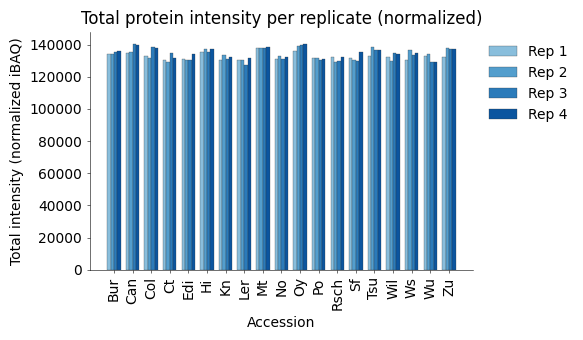

Saved: /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_median_intensity_normalized.pdf and /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_median_intensity_normalized.jpeg


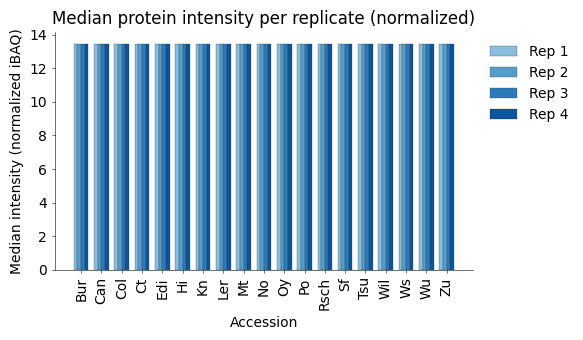

Saved: /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_missing_values_normalized.pdf and /home/ggiordano/snap/main/export/at_founders/arat_orthology/replicate_missing_values_normalized.jpeg


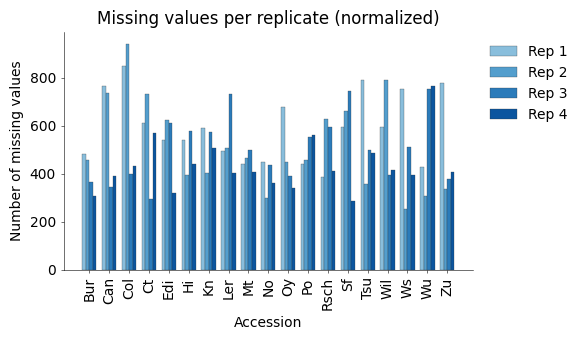


--- Protein group count consistency check ---
Bur: raw=10397 | normalized=10397 → OK
Can: raw=10768 | normalized=10768 → OK
Col: raw=10693 | normalized=10693 → OK
Ct: raw=10274 | normalized=10274 → OK
Edi: raw=10286 | normalized=10286 → OK
Hi: raw=10601 | normalized=10601 → OK
Kn: raw=10278 | normalized=10278 → OK
Ler: raw=10175 | normalized=10175 → OK
Mt: raw=10692 | normalized=10692 → OK
No: raw=10165 | normalized=10165 → OK
Oy: raw=10769 | normalized=10769 → OK
Po: raw=10223 | normalized=10223 → OK
Rsch: raw=10191 | normalized=10191 → OK
Sf: raw=10354 | normalized=10354 → OK
Tsu: raw=10624 | normalized=10624 → OK
Wil: raw=10395 | normalized=10395 → OK
Ws: raw=10398 | normalized=10398 → OK
Wu: raw=10282 | normalized=10282 → OK
Zu: raw=10581 | normalized=10581 → OK

Saved protein group count check: /home/ggiordano/snap/main/data/at_founders/orthology/pg_normalized/protein_group_count_check.tsv


In [12]:
# ---------------------------------------------------------
# Output directory for normalized data
# ---------------------------------------------------------

PG_NORM_DIR = DATA_DIR / "pg_normalized"
PG_NORM_DIR.mkdir(parents=True, exist_ok=True)

print("Normalized PG output directory:", PG_NORM_DIR)

# ---------------------------------------------------------
# Step 1 — compute sample medians
# ---------------------------------------------------------

sample_medians = []

for acc, df in pg_tables.items():

    ibaq_cols = [c for c in df.columns if "iBAQ" in c]

    for col in ibaq_cols:

        median_val = np.nanmedian(df[col].astype(float))

        sample_medians.append({
            "accession": acc,
            "replicate": col,
            "median_intensity": median_val
        })

sample_medians = pd.DataFrame(sample_medians)

# ---------------------------------------------------------
# Step 2 — compute grand median
# ---------------------------------------------------------

grand_median = np.nanmedian(sample_medians["median_intensity"])

print("Grand median:", grand_median)

# ---------------------------------------------------------
# Step 3 — compute correction factors
# ---------------------------------------------------------

sample_medians["correction_factor"] = (
    grand_median / sample_medians["median_intensity"]
)

print("\nCorrection factors:")
print(sample_medians.head())

# ---------------------------------------------------------
# Step 4 — apply normalization
# ---------------------------------------------------------

pg_tables_norm = {}

for acc, df in pg_tables.items():

    df_norm = df.copy()

    ibaq_cols = [c for c in df.columns if "iBAQ" in c]

    for col in ibaq_cols:

        factor = sample_medians.loc[
            sample_medians["replicate"] == col,
            "correction_factor"
        ].values[0]

        df_norm[col] = df_norm[col].astype(float) * factor

    pg_tables_norm[acc] = df_norm

    # save normalized table
    out_file = PG_NORM_DIR / f"{acc}_protein_groups_normalized.csv"
    df_norm.to_csv(out_file, index=False)

    print(f"{acc} normalized and saved")

# ---------------------------------------------------------
# Step 5 — recompute QC metrics on normalized data
# ---------------------------------------------------------

replicate_stats_norm = []

for acc, df in pg_tables_norm.items():

    ibaq_cols = [c for c in df.columns if "iBAQ" in c]

    for col in ibaq_cols:

        values = df[col].astype(float)

        replicate_stats_norm.append({
            "accession": acc,
            "replicate": col,
            "total_intensity": np.nansum(values),
            "median_intensity": np.nanmedian(values),
            "missing_values": values.isna().sum()
        })

replicate_stats_norm = pd.DataFrame(replicate_stats_norm)

print("\nNormalized QC summary:")
print(replicate_stats_norm.head())

# ---------------------------------------------------------
# Save normalized QC table
# ---------------------------------------------------------

qc_norm_file = PG_NORM_DIR / "replicate_qc_metrics_normalized.tsv"
replicate_stats_norm.to_csv(qc_norm_file, sep="\t", index=False)

print("Normalized QC metrics saved:", qc_norm_file)

# ensure consistent ordering
replicate_stats_norm = replicate_stats_norm.sort_values(["accession", "replicate"])

accessions = replicate_stats_norm["accession"].unique()
n_acc = len(accessions)

replicates_per_acc = replicate_stats_norm.groupby("accession").size().iloc[0]

x = np.arange(n_acc)
bar_width = 0.18

# blue palette (same as before)
rep_colors = sns.color_palette("Blues", n_colors=replicates_per_acc + 2)[2:]

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for i in range(replicates_per_acc):

    sub = replicate_stats_norm.groupby("accession").nth(i).reset_index()

    ax.bar(
        x + (i - replicates_per_acc/2)*bar_width + bar_width/2,
        sub["total_intensity"],
        width=bar_width,
        color=rep_colors[i],
        edgecolor="0.2",
        linewidth=0.2,
        label=f"Rep {i+1}"
    )

ax.set_ylabel("Total intensity (normalized iBAQ)")
ax.set_xlabel("Accession")
ax.set_title("Total protein intensity per replicate (normalized)")

ax.set_xticks(x)
ax.set_xticklabels(accessions, rotation=90)

sns.despine()
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.tick_params(width=0.4, length=2)

ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)

plt.tight_layout(rect=[0, 0, 0.85, 1])

fig_file = EXPORT_DIR / "replicate_total_intensity_normalized.pdf"
jpg_file = EXPORT_DIR / "replicate_total_intensity_normalized.jpeg"

plt.savefig(fig_file, dpi=300, bbox_inches="tight")
plt.savefig(jpg_file, dpi=300, bbox_inches="tight")

print("Saved:", fig_file, "and", jpg_file)

plt.show()

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for i in range(replicates_per_acc):

    sub = replicate_stats_norm.groupby("accession").nth(i).reset_index()

    ax.bar(
        x + (i - replicates_per_acc/2)*bar_width + bar_width/2,
        sub["median_intensity"],
        width=bar_width,
        color=rep_colors[i],
        edgecolor="0.2",
        linewidth=0.2,
        label=f"Rep {i+1}"
    )

ax.set_ylabel("Median intensity (normalized iBAQ)")
ax.set_xlabel("Accession")
ax.set_title("Median protein intensity per replicate (normalized)")

ax.set_xticks(x)
ax.set_xticklabels(accessions, rotation=90)

sns.despine()
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.tick_params(width=0.4, length=2)

ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)

plt.tight_layout(rect=[0, 0, 0.85, 1])

fig_file = EXPORT_DIR / "replicate_median_intensity_normalized.pdf"
jpg_file = EXPORT_DIR / "replicate_median_intensity_normalized.jpeg"

plt.savefig(fig_file, dpi=300, bbox_inches="tight")
plt.savefig(jpg_file, dpi=300, bbox_inches="tight")

print("Saved:", fig_file, "and", jpg_file)

plt.show()

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for i in range(replicates_per_acc):

    sub = replicate_stats_norm.groupby("accession").nth(i).reset_index()

    ax.bar(
        x + (i - replicates_per_acc/2)*bar_width + bar_width/2,
        sub["missing_values"],
        width=bar_width,
        color=rep_colors[i],
        edgecolor="0.2",
        linewidth=0.2,
        label=f"Rep {i+1}"
    )

ax.set_ylabel("Number of missing values")
ax.set_xlabel("Accession")
ax.set_title("Missing values per replicate (normalized)")

ax.set_xticks(x)
ax.set_xticklabels(accessions, rotation=90)

sns.despine()
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.tick_params(width=0.4, length=2)

ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)

plt.tight_layout(rect=[0, 0, 0.85, 1])

fig_file = EXPORT_DIR / "replicate_missing_values_normalized.pdf"
jpg_file = EXPORT_DIR / "replicate_missing_values_normalized.jpeg"

plt.savefig(fig_file, dpi=300, bbox_inches="tight")
plt.savefig(jpg_file, dpi=300, bbox_inches="tight")

print("Saved:", fig_file, "and", jpg_file)

plt.show()

# =========================================================
# CHECK: protein group counts (raw vs normalized)
# =========================================================

print("\n--- Protein group count consistency check ---")

pg_count_stats = []

for acc in sorted(pg_tables.keys()):

    n_raw = pg_tables[acc].shape[0]
    n_norm = pg_tables_norm[acc].shape[0]

    status = "OK" if n_raw == n_norm else "MISMATCH"

    pg_count_stats.append({
        "accession": acc,
        "n_protein_groups_raw": n_raw,
        "n_protein_groups_normalized": n_norm,
        "status": status
    })

    print(f"{acc}: raw={n_raw} | normalized={n_norm} → {status}")

# build summary table
pg_count_stats = pd.DataFrame(pg_count_stats)

# ---------------------------------------------------------
# Save summary
# ---------------------------------------------------------

count_file = PG_NORM_DIR / "protein_group_count_check.tsv"
pg_count_stats.to_csv(count_file, sep="\t", index=False)

print("\nSaved protein group count check:", count_file)

In [ ]:
#Make orthology matrix with identified proteins and iBAQ values (normalized)


import re
import numpy as np
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# Output
# ---------------------------------------------------------

OUT_DIR = DATA_DIR / "orthology_with_identified_proteins"
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_file = OUT_DIR / "orthology_matrix_with_identified_proteins_and_ibaq.tsv"

print("Output directory:", OUT_DIR)

# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------

def strip_pg_suffix(protein_id):
    if pd.isna(protein_id):
        return np.nan
    protein_id = str(protein_id).strip()
    protein_id = re.sub(r'_\d+$', '', protein_id)
    protein_id = re.sub(r'\.\d+$', '', protein_id)
    return protein_id


def strip_ortho_suffix(protein_id):
    if pd.isna(protein_id):
        return np.nan
    protein_id = str(protein_id).strip()
    protein_id = re.sub(r'_\d+$', '', protein_id)
    protein_id = re.sub(r'\.\d+$', '', protein_id)
    return protein_id


def split_orthology_cell(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    return [i.strip() for i in str(x).split(",") if i.strip()]


def resolve_accession(species_col, accession_keys):
    matches = [acc for acc in accession_keys if acc in species_col]

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1:
        matches = sorted(matches, key=len, reverse=True)
        return matches[0]

    return None


def safe_str_join(values):
    values = [str(v) for v in values if pd.notna(v) and str(v) != ""]
    if len(values) == 0:
        return np.nan
    return ", ".join(values)


# ---------------------------------------------------------
# Build lookup tables from NORMALIZED protein groups
# ---------------------------------------------------------

pg_match_tables = {}

for acc, df in pg_tables_norm.items():   # ← FIXED

    df2 = df.copy()

    df2["Protein.Group.original"] = df2["Protein.Group"].astype(str)
    df2["match_key"] = df2["Protein.Group.original"].apply(strip_pg_suffix)

    ibaq_cols = [c for c in df2.columns if "iBAQ" in c]

    df2 = df2[["Protein.Group.original", "match_key"] + ibaq_cols].copy()

    pg_match_tables[acc] = {
        "table": df2,
        "ibaq_cols": ibaq_cols
    }

    print(f"{acc}: {df2.shape[0]} rows | {len(ibaq_cols)} iBAQ columns")


# ---------------------------------------------------------
# Prepare expanded orthology matrix
# ---------------------------------------------------------

species_cols = orthology.columns[1:]
expanded_rows = []

for idx, row in orthology.iterrows():

    new_row = row.to_dict()

    for species_col in species_cols:

        acc = resolve_accession(species_col, pg_tables_norm.keys())  # ← FIXED

        if acc is None:
            print(f"Warning: could not resolve accession for column: {species_col}")
            continue

        pg_info = pg_match_tables[acc]
        pg_df = pg_info["table"]
        ibaq_cols = pg_info["ibaq_cols"]

        ortho_ids = split_orthology_cell(row[species_col])
        ortho_keys = {strip_ortho_suffix(x) for x in ortho_ids if pd.notna(x)}

        if len(ortho_keys) == 0:
            matched = pg_df.iloc[0:0].copy()
        else:
            matched = pg_df[pg_df["match_key"].isin(ortho_keys)].copy()

        new_row[f"{acc}_identified"] = safe_str_join(
            matched["Protein.Group.original"].tolist()
        )

        for i, col in enumerate(ibaq_cols, start=1):
            if matched.shape[0] == 0:
                new_row[f"{acc}_iBAQ_{i}"] = np.nan
            else:
                vals = matched[col].tolist()
                vals = [np.nan if pd.isna(v) else v for v in vals]
                new_row[f"{acc}_iBAQ_{i}"] = safe_str_join(vals)

    expanded_rows.append(new_row)

    if (idx + 1) % 1000 == 0:
        print(f"Processed {idx + 1} orthogroups...")

expanded_matrix = pd.DataFrame(expanded_rows)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

expanded_matrix.to_csv(out_file, sep="\t", index=False)

print("Saved:", out_file)
print("Final shape:", expanded_matrix.shape)


# =========================================================
# Reorder columns
# =========================================================

df = expanded_matrix.copy()

base_cols = [df.columns[0]]
species_cols = orthology.columns[1:]

new_order = base_cols.copy()

for species_col in species_cols:

    new_order.append(species_col)

    acc = None
    matches = [a for a in pg_tables_norm.keys() if a in species_col]  # ← FIXED

    if len(matches) == 1:
        acc = matches[0]
    elif len(matches) > 1:
        acc = sorted(matches, key=len, reverse=True)[0]

    if acc is None:
        continue

    id_col = f"{acc}_identified"
    if id_col in df.columns:
        new_order.append(id_col)

    i = 1
    while True:
        ibaq_col = f"{acc}_iBAQ_{i}"
        if ibaq_col in df.columns:
            new_order.append(ibaq_col)
            i += 1
        else:
            break

remaining = [c for c in df.columns if c not in new_order]
new_order.extend(remaining)

df = df[new_order]

reordered_file = OUT_DIR / "orthology_matrix_reordered.tsv"
df.to_csv(reordered_file, sep="\t", index=False)

print("Reordered file saved:", reordered_file)
print("Final column count:", len(df.columns))


Output directory: /home/ggiordano/snap/main/data/at_founders/orthology/orthology_with_identified_proteins
Bur: 10397 rows | 4 iBAQ columns
Can: 10768 rows | 4 iBAQ columns
Col: 10693 rows | 4 iBAQ columns
Ct: 10274 rows | 4 iBAQ columns
Edi: 10286 rows | 4 iBAQ columns
Hi: 10601 rows | 4 iBAQ columns
Kn: 10278 rows | 4 iBAQ columns
Ler: 10175 rows | 4 iBAQ columns
Mt: 10692 rows | 4 iBAQ columns
No: 10165 rows | 4 iBAQ columns
Oy: 10769 rows | 4 iBAQ columns
Po: 10223 rows | 4 iBAQ columns
Rsch: 10191 rows | 4 iBAQ columns
Sf: 10354 rows | 4 iBAQ columns
Tsu: 10624 rows | 4 iBAQ columns
Wil: 10395 rows | 4 iBAQ columns
Ws: 10398 rows | 4 iBAQ columns
Wu: 10282 rows | 4 iBAQ columns
Zu: 10581 rows | 4 iBAQ columns
Processed 1000 orthogroups...
Processed 2000 orthogroups...
Processed 3000 orthogroups...
Processed 4000 orthogroups...
Processed 5000 orthogroups...
Processed 6000 orthogroups...
Processed 7000 orthogroups...
Processed 8000 orthogroups...
Processed 9000 orthogroups...
Process

NameError: name 'unassigned_dict' is not defined

In [ ]:
##Check unassigned genes and if all protein groups are included in matrix. 
#I noticed that not all of them are included 


# =========================================================
# Check unassigned genes identification (CORRECTED)
# =========================================================

print("\n=== UNASSIGNED GENES IDENTIFICATION CHECK ===")

unassigned_summary = []

for acc, genes in unassigned_dict.items():

    print(f"\n--- {acc} ---")

    # normalize
    genes = {strip_ortho_suffix(g) for g in genes if pd.notna(g)}

    # ----------------------------------------
    # Extract identified genes from FINAL matrix
    # ----------------------------------------
    id_col = f"{acc}_identified"

    identified_genes = set()

    if id_col in df.columns:
        for cell in df[id_col].dropna():
            proteins = [p.strip() for p in str(cell).split(",") if p.strip()]
            proteins = [strip_pg_suffix(p) for p in proteins]
            identified_genes.update(proteins)

    # ----------------------------------------
    # INTERSECTION (this is the key step)
    # ----------------------------------------
    identified_unassigned = genes.intersection(identified_genes)

    # ----------------------------------------
    # Stats
    # ----------------------------------------
    n_total = len(genes)
    n_identified = len(identified_unassigned)

    print(f"Total unassigned genes: {n_total}")
    print(f"Identified:            {n_identified}")

    if n_total > 0:
        print(f"% identified:         {n_identified / n_total * 100:.2f}%")

    print(f"Example identified:   {list(identified_unassigned)[:10]}")
    print(f"Example NOT detected: {list(genes - identified_unassigned)[:10]}")

    # store
    unassigned_summary.append({
        "accession": acc,
        "total_unassigned": n_total,
        "identified": n_identified,
        "percent_identified": (n_identified / n_total * 100) if n_total > 0 else 0
    })

# save
unassigned_df = pd.DataFrame(unassigned_summary)

out_file = OUT_DIR / "unassigned_identification_summary.tsv"
unassigned_df.to_csv(out_file, sep="\t", index=False)

print("\nSaved:", out_file)

# =========================================================
# CHECK: protein group coverage + export missing proteins
# =========================================================

print("\n=== PROTEIN GROUP COVERAGE CHECK (WITH EXPORT) ===")

coverage_summary = []
missing_all = []

# directory for missing proteins
MISSING_DIR = OUT_DIR / "missing_protein_groups"
MISSING_DIR.mkdir(parents=True, exist_ok=True)

for acc, pg_info in pg_match_tables.items():

    print(f"\n--- {acc} ---")

    pg_df = pg_info["table"]

    # ----------------------------------------
    # ALL protein groups
    # ----------------------------------------
    all_pg = set(pg_df["Protein.Group.original"].dropna().astype(str))

    # ----------------------------------------
    # Protein groups FOUND in orthology matrix
    # ----------------------------------------
    id_col = f"{acc}_identified"

    identified_pg = set()

    if id_col in df.columns:
        for cell in df[id_col].dropna():
            proteins = [p.strip() for p in str(cell).split(",") if p.strip()]
            identified_pg.update(proteins)

    # ----------------------------------------
    # Missing protein groups
    # ----------------------------------------
    missing_pg = all_pg - identified_pg

    # ----------------------------------------
    # Stats
    # ----------------------------------------
    n_total = len(all_pg)
    n_mapped = len(identified_pg)
    n_missing = len(missing_pg)

    coverage = (n_mapped / n_total * 100) if n_total > 0 else 0

    print(f"Total protein groups: {n_total}")
    print(f"Mapped in matrix:     {n_mapped}")
    print(f"Missing:              {n_missing}")
    print(f"Coverage:             {coverage:.2f}%")

    print(f"Example missing: {list(missing_pg)[:10]}")

    # ----------------------------------------
    # SAVE per-accession missing list
    # ----------------------------------------
    missing_df = pd.DataFrame({
        "accession": acc,
        "Protein.Group": list(missing_pg)
    })

    missing_file = MISSING_DIR / f"{acc}_missing_protein_groups.tsv"
    missing_df.to_csv(missing_file, sep="\t", index=False)

    print(f"Saved missing list: {missing_file}")

    # ----------------------------------------
    # Add to global list
    # ----------------------------------------
    missing_all.extend([
        {"accession": acc, "Protein.Group": pg}
        for pg in missing_pg
    ])

    # ----------------------------------------
    # Store summary
    # ----------------------------------------
    coverage_summary.append({
        "accession": acc,
        "total_protein_groups": n_total,
        "mapped_protein_groups": n_mapped,
        "missing_protein_groups": n_missing,
        "coverage_percent": coverage
    })


# ----------------------------------------
# Save coverage summary
# ----------------------------------------
coverage_df = pd.DataFrame(coverage_summary)

coverage_file = OUT_DIR / "protein_group_coverage_summary.tsv"
coverage_df.to_csv(coverage_file, sep="\t", index=False)

print("\nCoverage summary saved:", coverage_file)

# ----------------------------------------
# Save combined missing proteins
# ----------------------------------------
missing_all_df = pd.DataFrame(missing_all)

missing_all_file = OUT_DIR / "all_missing_protein_groups.tsv"
missing_all_df.to_csv(missing_all_file, sep="\t", index=False)

print("Combined missing protein list saved:", missing_all_file)

In [ ]:
#Here we attach annotations to the matrix. Only problem is that we annotate only Col proteins so we will have a lot of missing annotations for the other speciees. 
#For the moment we leave it as it is but in the future we can think about how to annotate the other species as well.

# =========================================================
# Annotate orthology matrix with UniProt + functional info
# =========================================================

print("\n--- Starting annotation step ---")

annot_df = df.copy()  # your reordered matrix

# ---------------------------------------------------------
# 1. Extract Col representative (first isoform in orthogroup)
# ---------------------------------------------------------

col_col = "ddAraThal.Col0.ZZ.V1.annot3.peps.longest.isoforms"

def get_first_entry(x):
    if pd.isna(x) or str(x).strip() == "":
        return np.nan
    return str(x).split(",")[0].strip()

annot_df["Col_representative"] = annot_df[col_col].apply(get_first_entry)

print("Col representative extracted")

# ---------------------------------------------------------
# 2. Load DIAMOND mapping (Col → UniProt)
# ---------------------------------------------------------

diamond_file = Path("/home/ggiordano/snap/main/import/at_founders/col0mott_vs_col0_uniprot/col0_vs_tair.tsv")

diamond = pd.read_csv(diamond_file, sep="\t", header=None)

diamond.columns = [
    "Col_protein",
    "UniProt",
    "pident",
    "length",
    "mismatch",
    "gapopen",
    "evalue",
    "bitscore"
]

# keep only relevant columns
diamond = diamond[["Col_protein", "UniProt"]].copy()

# remove duplicates (keep best hit = first)
diamond = diamond.drop_duplicates(subset="Col_protein")

print("Diamond mapping loaded:", diamond.shape)

# ---------------------------------------------------------
# 3. Map UniProt IDs
# ---------------------------------------------------------

annot_df = annot_df.merge(
    diamond,
    left_on="Col_representative",
    right_on="Col_protein",
    how="left"
)

annot_df.rename(columns={"UniProt": "Col_UniProt"}, inplace=True)

# clean UniProt (remove sp| |)
def clean_uniprot(x):
    if pd.isna(x):
        return np.nan
    parts = str(x).split("|")
    if len(parts) >= 2:
        return parts[1]
    return x

annot_df["Col_UniProt"] = annot_df["Col_UniProt"].apply(clean_uniprot)

print("UniProt mapping added")

# ---------------------------------------------------------
# 4. Load UniProt annotations
# ---------------------------------------------------------

annot_file = Path("/home/ggiordano/snap/main/import/at_founders/at_TAIR10_proteome_annotations/at_ref_proteome_UP000006548_2026_03_15.tsv")

uniprot_annot = pd.read_csv(annot_file, sep="\t")

print("Annotation file loaded:", uniprot_annot.shape)

# ---------------------------------------------------------
# 5. Merge annotations
# ---------------------------------------------------------

annot_df = annot_df.merge(
    uniprot_annot,
    left_on="Col_UniProt",
    right_on="Entry",
    how="left"
)

print("Functional annotation added")

# ---------------------------------------------------------
# 6. Optional: keep only key annotation columns
# ---------------------------------------------------------

keep_cols = [
    "Orthogroup",
    "Col_representative",
    "Col_UniProt",
    "Protein names",
    "Gene Names",
    "Gene Ontology (biological process)",
    "Gene Ontology (molecular function)",
    "Gene Ontology (cellular component)",
    "InterPro"
]

# ensure they exist
keep_cols = [c for c in keep_cols if c in annot_df.columns]

# move them to front
remaining_cols = [c for c in annot_df.columns if c not in keep_cols]
annot_df = annot_df[keep_cols + remaining_cols]

# ---------------------------------------------------------
# 7. Save annotated matrix
# ---------------------------------------------------------

annotated_file = OUT_DIR / "orthology_matrix_reordered_annotated.tsv"

annot_df.to_csv(annotated_file, sep="\t", index=False)

print("Annotated file saved:", annotated_file)
print("Final shape:", annot_df.shape)
print([c for c in annot_df.columns if "Col0" in c])


# =========================================================
# Final column reordering (publication-ready layout)
# =========================================================

print("\n--- Reordering into final structure ---")

df_final = annot_df.copy()

# ---------------------------------------------------------
# Core columns (Col reference + annotation)
# ---------------------------------------------------------

core_cols = [
    "Orthogroup",
    "ddAraThal.Col0.ZZ.V1.annot3.peps.longest.isoforms",
    "Col_representative",
    "Col_UniProt",
    "Protein names",
    "Gene Names",
    "Gene Ontology (biological process)",
    "Gene Ontology (molecular function)",
    "Gene Ontology (cellular component)",
    "InterPro",
    "Col_identified"
]

# add Col iBAQ columns
col_ibaq_cols = [c for c in df_final.columns if c.startswith("Col_iBAQ_")]
col_ibaq_cols = sorted(col_ibaq_cols)

core_cols += col_ibaq_cols

# keep only existing
core_cols = [c for c in core_cols if c in df_final.columns]

# ---------------------------------------------------------
# Add other accessions in structured blocks
# ---------------------------------------------------------

all_cols = set(df_final.columns)
used_cols = set(core_cols)

final_order = core_cols.copy()

# find all accession prefixes dynamically
accessions = sorted(set(
    c.split("_")[0]
    for c in df_final.columns
    if "_identified" in c and not c.startswith("Col_")
))

for acc in accessions:

    # isoform column
    isoform_cols = [c for c in df_final.columns if acc in c and "longest.isoforms" in c]

    # identified column
    id_col = f"{acc}_identified"

    # iBAQ columns
    ibaq_cols = [c for c in df_final.columns if c.startswith(f"{acc}_iBAQ_")]
    ibaq_cols = sorted(ibaq_cols)

    # append in order
    for col in isoform_cols:
        final_order.append(col)

    if id_col in df_final.columns:
        final_order.append(id_col)

    final_order.extend(ibaq_cols)

# ---------------------------------------------------------
# Add remaining columns (safety)
# ---------------------------------------------------------

remaining = [c for c in df_final.columns if c not in final_order]
final_order.extend(remaining)

df_final = df_final[final_order]

# ---------------------------------------------------------
# Save final matrix
# ---------------------------------------------------------

final_file = OUT_DIR / "orthology_matrix_final.tsv"

df_final.to_csv(final_file, sep="\t", index=False)

print("Final matrix saved:", final_file)
print("Final column count:", len(df_final.columns))


In [ ]:
# =========================================================
# PCA — PROTEIN GROUPS (REPLICATES)
# =========================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PCA_DIR = EXPORT_DIR / "pca_protein_groups"
PCA_DIR.mkdir(parents=True, exist_ok=True)

print("\nPCA output directory:", PCA_DIR)

# ---------------------------------------------------------
# Build matrix (protein groups × replicates)
# ---------------------------------------------------------

print("\n--- PCA: protein groups (replicates, no averaging) ---")

pg_long = []

for acc, df in pg_tables_norm.items():

    ibaq_cols = [c for c in df.columns if "iBAQ" in c]

    for col in ibaq_cols:

        tmp = pd.DataFrame({
            "Protein.Group": df["Protein.Group"].astype(str),
            "value": pd.to_numeric(df[col], errors="coerce"),
            "sample": f"{acc}_{col}",
            "accession": acc
        })

        pg_long.append(tmp)

pg_long = pd.concat(pg_long)

pg_matrix = pg_long.pivot_table(
    index="Protein.Group",
    columns="sample",
    values="value",
    aggfunc="mean"
).fillna(0)

metadata = pg_long[["sample", "accession"]].drop_duplicates()

# ---------------------------------------------------------
# PCA
# ---------------------------------------------------------

X = pg_matrix.T.copy()

# remove zero-variance features
X = X.loc[:, X.var(axis=0) > 0]

# log transform
X = np.log2(X + 1)

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
pca_df["sample"] = X.index
pca_df = pca_df.merge(metadata, on="sample")

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

palette = dict(zip(
    pca_df["accession"].unique(),
    sns.color_palette("tab20", n_colors=pca_df["accession"].nunique())
))

# scatter only
for acc, sub in pca_df.groupby("accession"):

    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        s=45,
        color=palette[acc],
        label=acc
    )

# axes
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.set_title("PCA — Protein Groups (replicates)")

sns.despine()
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.tick_params(width=0.4, length=2)

# legend (two columns)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    ncol=2
)

plt.tight_layout(rect=[0, 0, 0.8, 1])

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

pdf_file = PCA_DIR / "pca_protein_groups_replicates.pdf"
jpg_file = PCA_DIR / "pca_protein_groups_replicates.jpeg"

plt.savefig(pdf_file, dpi=300)
plt.savefig(jpg_file, dpi=300)

print("Saved:", pdf_file, "and", jpg_file)

plt.show()